# AlexNet (single-stream)

**Why single-stream instead of the original 2-GPU split.** The original
AlexNet split the network across two GPUs purely due to memory constraints
of the GTX 580 (3GB) available in 2012, not as an architectural choice. We
run the network as a single stream on one device (MPS), which is
mathematically equivalent to the merged version of the original two-stream
design.

In [1]:
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
import os
import urllib.request
import tarfile

DATA_DIR = "../data"
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

if not os.path.exists(IMAGENETTE_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    tgz_path = os.path.join(DATA_DIR, "imagenette2.tgz")
    print("Downloading Imagenette...")
    urllib.request.urlretrieve(IMAGENETTE_URL, tgz_path)
    print("Extracting...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(DATA_DIR)
    os.remove(tgz_path)
    print("Done.")
else:
    print("Imagenette already downloaded.")

Extracting...


/var/folders/vz/v9jd0q21113gy1bc9ymp039m0000gn/T/ipykernel_27327/2347913026.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Done.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


model = AlexNet(num_classes=10).to(device)
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, 

In [5]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [6]:
def count_conv_params(in_ch, out_ch, kernel_size):
    return (kernel_size * kernel_size * in_ch + 1) * out_ch

def count_fc_params(in_features, out_features):
    return (in_features + 1) * out_features

conv1 = count_conv_params(3, 96, 11)
conv2 = count_conv_params(96, 256, 5)
conv3 = count_conv_params(256, 384, 3)
conv4 = count_conv_params(384, 384, 3)
conv5 = count_conv_params(384, 256, 3)
fc6 = count_fc_params(256 * 6 * 6, 4096)
fc7 = count_fc_params(4096, 4096)
fc8 = count_fc_params(4096, 10)  # 10 classes (not 1000)

manual_total = conv1 + conv2 + conv3 + conv4 + conv5 + fc6 + fc7 + fc8
torch_total = sum(p.numel() for p in model.parameters())

print(f"CONV1: {conv1:,}")
print(f"CONV2: {conv2:,}")
print(f"CONV3: {conv3:,}")
print(f"CONV4: {conv4:,}")
print(f"CONV5: {conv5:,}")
print(f"FC6: {fc6:,}")
print(f"FC7: {fc7:,}")
print(f"FC8: {fc8:,}")
print(f"Manual total: {manual_total:,}")
print(f"torch total:  {torch_total:,}")
assert manual_total == torch_total, "Mismatch between manual and torch parameter count"

CONV1: 34,944
CONV2: 614,656
CONV3: 885,120
CONV4: 1,327,488
CONV5: 884,992
FC6: 37,752,832
FC7: 16,781,312
FC8: 40,970
Manual total: 58,322,314
torch total:  58,322,314


**Why Adam instead of SGD with momentum.** The original paper used SGD with
momentum=0.9 and a hand-tuned learning rate schedule. We used Adam for
simpler, more reliable convergence without manual tuning, especially given
we only train for a single epoch.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
NUM_EPOCHS = 20
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/20 | train_loss=1.8138 train_acc=0.3667 | val_loss=1.6328 val_acc=0.4390 | time=49.8s
Epoch 2/20 | train_loss=1.5893 train_acc=0.4641 | val_loss=1.3668 val_acc=0.5282 | time=50.4s
Epoch 3/20 | train_loss=1.4050 train_acc=0.5270 | val_loss=1.1904 val_acc=0.6061 | time=50.6s
Epoch 4/20 | train_loss=1.3074 train_acc=0.5660 | val_loss=1.0942 val_acc=0.6375 | time=50.5s
Epoch 5/20 | train_loss=1.2174 train_acc=0.6016 | val_loss=0.9679 val_acc=0.6800 | time=50.5s
Epoch 6/20 | train_loss=1.1546 train_acc=0.6233 | val_loss=0.9576 val_acc=0.6983 | time=50.7s
Epoch 7/20 | train_loss=1.0894 train_acc=0.6404 | val_loss=0.8425 val_acc=0.7223 | time=50.7s
Epoch 8/20 | train_loss=1.0380 train_acc=0.6640 | val_loss=0.7977 val_acc=0.7394 | time=50.7s
Epoch 9/20 | train_loss=0.9983 train_acc=0.6743 | val_loss=0.7960 val_acc=0.7401 | time=50.6s
Epoch 10/20 | train_loss=0.9772 train_acc=0.6834 | val_loss=0.8382 val_acc=0.7271 | time=50.6s
Epoch 11/20 | train_loss=0.9398 train_acc=0.6958 | val_loss

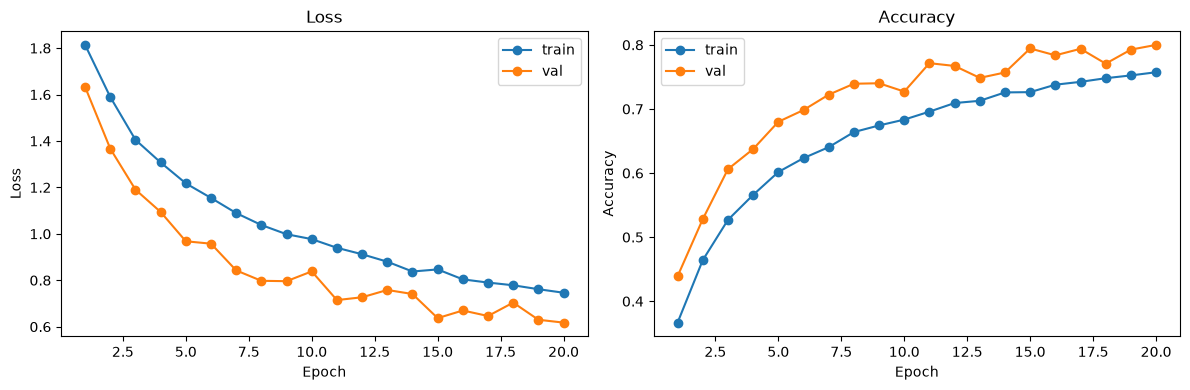

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

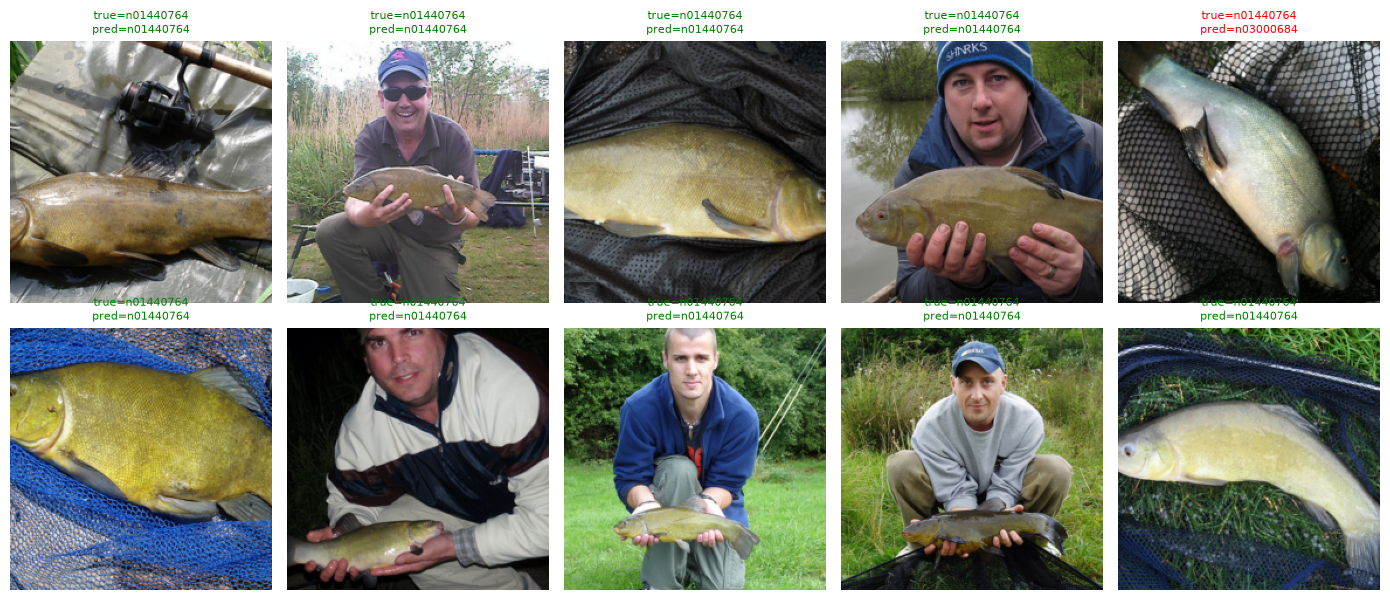

In [13]:
model.eval()
sample_images, sample_labels = next(iter(val_loader))
class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: see manual vs. torch count
above (58,322,314). As in the original paper, the bulk of parameters
sits in the fully connected layers (FC6/FC7/FC8), not the convolutional
layers — the five conv layers combined contain far fewer parameters than
FC6 alone.


**Why 10 output classes instead of 1000.** Imagenette is a 10-class subset
of ImageNet, so the final FC8 layer was sized accordingly instead of the
original 1000-way classifier. All other architectural parameters (input
size 224×224, kernel sizes, strides, channel counts, dropout) are kept
identical to the original paper.